# Data Exploration

This notebook explores the financial news dataset and performs initial analysis.

In [ ]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.collector import DataCollector
from src.data.preprocessor import DataPreprocessor

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [ ]:
# Load your data here
# collector = DataCollector()
# df = collector.load_from_csv('data/raw/financial_news.csv')

# For demonstration, create sample data
df = pd.DataFrame({
    'text': [
        'Apple reports strong quarterly earnings, stock surges 5%',
        'Market volatility increases as investors worry about inflation',
        'Tech stocks rally on positive economic data',
        'Company announces major layoffs, stock price declines',
        'Federal Reserve signals potential rate cuts',
    ],
    'date': pd.date_range('2024-01-01', periods=5),
    'source': ['Reuters', 'Bloomberg', 'CNBC', 'WSJ', 'FT']
})

print(f"Dataset shape: {df.shape}")
df.head()

## Data Overview

In [ ]:
# Basic statistics
print("Dataset Info:")
print(df.info())
print("\n")
print("Missing Values:")
print(df.isnull().sum())

## Text Length Distribution

In [ ]:
df['text_length'] = df['text'].str.len()

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=20, edgecolor='black')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths')
plt.show()

## Preprocessing

In [ ]:
preprocessor = DataPreprocessor()
df_clean = preprocessor.preprocess_dataframe(df)

print(f"Original records: {len(df)}")
print(f"Cleaned records: {len(df_clean)}")
df_clean.head()

## FinBERT 验证 FNSPID数据集
测试 FinBERT模型验证FNSPID_data数据集是否有效

In [ ]:
# def extract_and_predict():
"""
从测试集抽取1000条有效样本并进行FinBERT预测
"""

print("="*60)
print("Step 1: 读取测试集并抽取样本")
print("="*60)

# 读取测试集（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

print("正在读取测试集...")
df = pd.read_csv("02_A_finbert/FNSPID_data/test.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行（所有行都有，但确保安全）
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 随机抽取1000条
sample_size = 1000
sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"抽取样本数: {len(sampled_df)}")

# 保存抽取的样本
sample_path = "02_A_finbert/FNSPID_data/test_sample_1000.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"样本已保存到: {sample_path}")


Step 1: 读取测试集并抽取样本
正在读取测试集...


总样本数: 1,958,628
有效样本数: 1,958,628
抽取样本数: 1000
样本已保存到: 02_A_finbert/FNSPID_data/test_sample_1000.csv


In [ ]:

print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)
from transformers import AutoTokenizer, AutoModelForSequenceClassification



Step 2: 加载 FinBERT 模型


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: 02_A_finbert/finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!


In [ ]:

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")

使用设备: cuda


In [ ]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)

# 准备文本
texts = sampled_df['Article_title'].fillna('').tolist()

# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



Step 3: 批量预测情感


预测进度: 100%|██████████| 16/16 [00:01<00:00,  8.85it/s]


In [ ]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

# 保存完整结果
output_path = "./02_A_finbert/finbert_output/FNSPID_1000_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")




Step 4: 结果分析

情感分数统计:
  均值: 0.0605
  标准差: 0.4641
  最小值: -1.0000
  最大值: 1.0000

情感标签分布:
  neutral: 759 (75.9%)
  positive: 150 (15.0%)
  negative: 91 (9.1%)

按股票代码的情感分布 (Top 10):
                  mean  count
Stock_symbol                 
AMTD         -0.189071      2
ATW          -0.499710      2
BBRY         -0.308040      2
CCJ           0.500000      2
DUK          -0.000389      2
GNW          -0.996162      2
GPOR          0.500114      2
JPM          -0.001460      2
MRVL          0.161054      2
PNR          -0.000015      2

✅ 预测结果已保存到: ./02_A_finbert/finbert_output/FNSPID_1000_predictions.csv
   文件大小: 0.26 MB

Step 5: 高置信度样本展示（供人工验证）

样本 1:
  日期: 2013-07-22 00:00:00 UTC
  股票: N/A
  预测: negative (分数: -1.000)
  概率: 负=1.000, 中=0.000, 正=0.000
  标题: Mobistar Slumps Most Since IPO on Lower Outlook: Brussels Mover...

样本 12:
  日期: 2014-11-12 00:00:00 UTC
  股票: MWV
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Apogee Hits 52-Week High on Strong Architectural Market

情感分数分布:
count    1000.000000
mean        0.060544
std         0.464129
min        -1.000000
25%        -0.000262
50%        -0.000005
75%         0.001758
max         1.000000
Name: sentiment_score, dtype: float64


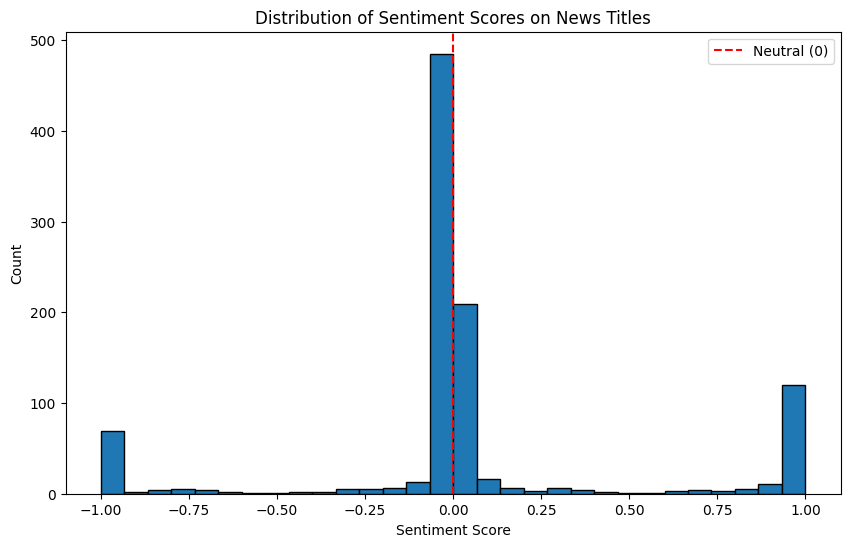


最正面样本:
  Score: 1.000 | Chegg shares are trading higher after Morgan Stanley reinsta
  Score: 1.000 |  Canacol Energy Ltd. Announces 227% Increase in Revenues and
  Score: 1.000 | Medical Marijuana Inc. in a Strong Market Position with Amen
  Score: 1.000 | SolidFire Broadens Market Reach Delivering New Scale-Out All
  Score: 1.000 | Nokia (NOK) Earnings and Revenues Surpass Estimates in Q4

最负面样本:
  Score: -1.000 | UPDATE 2-Cenovus slows Foster Creek expansion; earnings disa
  Score: -1.000 | Pentair plc. Ordinary Share Lowers FY2019 EPS Guidance from 
  Score: -1.000 | TEX-S&P;: 3 most stressed sectors hurt by slow recovery
  Score: -1.000 | Fitch: UK Non-Life London Market Insurance Continues to Face
  Score: -1.000 | Consumer confidence lowest since Katrina

模型不确定性:
  平均不确定性: 0.247
  高不确定性样本(>0.5): 242 条


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/finbert_output/FNSPID_1000_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")

## FinBERT 验证 BBC数据集


In [ ]:
df = pd.read_csv("02_A_finbert/bbc_data/bbc_news.csv")

print(f"原始数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"总样本数: {len(df)}")
df.head(5)


原始数据形状: (42115, 5)
列名: ['title', 'pubDate', 'guid', 'link', 'description']
总样本数: 42115


,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [ ]:

# 数据探索
print(f"\n数据集基本信息:")
print(f"总样本数: {len(df):,}")
print(f"缺失值统计:")
print(df.isnull().sum())

# 创建用于分析的文本列（结合标题和描述）
print("\n" + "="*60)
print("Step 2: 数据预处理")
print("="*60)

# 填充缺失值
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')

# 创建完整文本（标题 + 描述）
# 方式1: 只使用标题（更快）
# df['text'] = df['title']

# 方式2: 结合标题和描述（更全面）
df['text'] = df['title'] + " " + df['description']

# 过滤空文本
valid_df = df[df['text'].str.strip() != ''].copy()
print(f"有效样本数: {len(valid_df):,}")
print(f"移除空文本: {len(df) - len(valid_df)} 条")

# 文本长度统计
text_lengths = valid_df['text'].str.len()
print(f"\n文本长度统计:")
print(f"  平均长度: {text_lengths.mean():.1f} 字符")
print(f"  中位数: {text_lengths.median():.0f} 字符")
print(f"  最大长度: {text_lengths.max():,} 字符")
print(f"  最小长度: {text_lengths.min():.0f} 字符")

# 随机抽取样本（可选）
sample_size = None  # 设置为None使用全部数据，或设置数字如1000

if sample_size and sample_size < len(valid_df):
    sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    print(f"\n抽取样本数: {len(sampled_df):,}")
else:
    sampled_df = valid_df.reset_index(drop=True)
    print(f"\n使用全部样本: {len(sampled_df):,}")

# 保存处理后的样本
sample_path = "02_A_finbert/bbc_data/bbc_news_processed.csv"
sampled_df.to_csv(sample_path, index=False)
print(f"处理后的数据已保存到: {sample_path}")



数据集基本信息:
总样本数: 42,115
缺失值统计:
title          0
pubDate        0
guid           0
link           0
description    0
dtype: int64

Step 2: 数据预处理
有效样本数: 42,115
移除空文本: 0 条

文本长度统计:
  平均长度: 164.5 字符
  中位数: 158 字符
  最大长度: 332 字符
  最小长度: 34 字符

使用全部样本: 42,115
处理后的数据已保存到: 02_A_finbert/bbc_data/bbc_news_processed.csv


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "02_A_finbert/finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: 02_A_finbert/finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!


In [ ]:

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")

使用设备: cuda


In [ ]:

print("\n" + "="*60)
print("Step 3: 批量预测情感")
print("="*60)


# # 准备文本
# texts = sampled_df['Article_title'].fillna('').tolist()
texts = sampled_df['text'].tolist()


# 批量预测
batch_size = 64
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
    batch_texts = texts[i:i+batch_size]
    
    # 编码
    inputs = tokenizer(batch_texts, return_tensors="pt", 
                        truncation=True, max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # 预测
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    # 解析结果
    for j, prob in enumerate(probs):
        # neg = prob[0].item()
        # neu = prob[1].item()
        # pos = prob[2].item()
        # update
        neg = prob[2].item()
        neu = prob[0].item()
        pos = prob[1].item()
        
        score = pos - neg  # 情感分数 -1 到 1
        
        # # 分类标签（阈值可调整）
        # if score > 0.2:
        #     label = "positive"
        # elif score < -0.2:
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 更宽松的阈值
        # if score > 0.05:  # 原来是 0.2
        #     label = "positive"
        # elif score < -0.05:  # 原来是 -0.2
        #     label = "negative"
        # else:
        #     label = "neutral"

        # 使用最高概率判断（更准确）
        if neu > pos and neu > neg:
            label = "neutral"
        elif pos > neg:
            label = "positive"
        else:
            label = "negative"
        
        
        results.append({
            'sentiment_score': score,
            'predicted_label': label,
            'negative_prob': neg,
            'neutral_prob': neu,
            'positive_prob': pos
        })

# 合并结果
result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)



Step 3: 批量预测情感


预测进度: 100%|██████████| 659/659 [01:15<00:00,  8.69it/s]


In [ ]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)

# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {result_df['sentiment_score'].max():.4f}")
print(f"  中位数: {result_df['sentiment_score'].median():.4f}")

print(f"\n情感标签分布:")
label_counts = result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(result_df)*100:.1f}%)")

# # 按股票代码统计（如果有股票代码）
# if result_df['Stock_symbol'].notna().any():
#     print(f"\n按股票代码的情感分布 (Top 10):")
#     stock_stats = result_df[result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
#     stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
#     print(stock_stats.head(10))
# else:
#     print(f"\n注意: 抽取的样本中没有股票代码信息")

    
# 按时间分析（如果有pubDate）
if 'pubDate' in result_df.columns:
    print(f"\n按时间的情感趋势:")
    result_df['pubDate'] = pd.to_datetime(result_df['pubDate'], errors='coerce')
    
    # 按日期分组
    daily_sentiment = result_df.groupby(result_df['pubDate'].dt.date)['sentiment_score'].agg(['mean', 'count'])
    print(f"日期范围: {daily_sentiment.index.min()} 至 {daily_sentiment.index.max()}")
    print(f"平均每日样本数: {daily_sentiment['count'].mean():.1f}")
    
    # 显示前10天
    print(f"\n最近10天的平均情感分数:")
    print(daily_sentiment.tail(10))





# 按标题关键词分组分析（可选）
print(f"\n高情感强度新闻示例:")
# 最正面新闻
positive_top = result_df.nlargest(5, 'sentiment_score')[['title', 'sentiment_score', 'predicted_label']]
print("\n最正面新闻:")
for idx, row in positive_top.iterrows():
    print(f"  [{row['sentiment_score']:.3f}] {row['title'][:80]}...")

# 最负面新闻
negative_top = result_df.nsmallest(5, 'sentiment_score')[['title', 'sentiment_score', 'predicted_label']]
print("\n最负面新闻:")
for idx, row in negative_top.iterrows():
    print(f"  [{row['sentiment_score']:.3f}] {row['title'][:80]}...")

# 保存完整结果
output_path = "02_A_finbert/bbc_output/bbc_news_sentiment_predictions.csv"
result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

# 保存统计摘要
summary = {
    'total_samples': len(result_df),
    'mean_sentiment': result_df['sentiment_score'].mean(),
    'std_sentiment': result_df['sentiment_score'].std(),
    'positive_count': (result_df['predicted_label'] == 'positive').sum(),
    'neutral_count': (result_df['predicted_label'] == 'neutral').sum(),
    'negative_count': (result_df['predicted_label'] == 'negative').sum(),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("02_A_finbert/bbc_output/bbc_news_sentiment_summary.csv", index=False)
print(f"统计摘要已保存到: bbc_news_sentiment_summary.csv")

print("\n" + "="*60)
print("Step 6: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = result_df[
    (result_df['negative_prob'] > 0.8) | 
    (result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['pubDate'] if pd.notna(row.get('pubDate')) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['title'][:150]}...")
        if pd.notna(row.get('description')):
            print(f"  描述: {row['description'][:150]}...")
else:
    print("没有找到高置信度样本（置信度 > 80%）")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = result_df[
    (result_df['sentiment_score'] > -0.1) & 
    (result_df['sentiment_score'] < 0.1)
].head(5)

if len(neutral_samples) > 0:
    for idx, row in neutral_samples.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  标题: {row['title'][:100]}...")
        print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")
else:
    print("没有找到边界样本")
                        





Step 4: 结果分析

情感分数统计:
  均值: -0.1211
  标准差: 0.4905
  最小值: -1.0000
  最大值: 1.0000
  中位数: -0.0002

情感标签分布:
  neutral: 29921 (71.0%)
  negative: 8606 (20.4%)
  positive: 3588 (8.5%)

按时间的情感趋势:
日期范围: 2013-08-30 至 2024-12-04
平均每日样本数: 41.2

最近10天的平均情感分数:
                mean  count
pubDate                    
2024-11-25 -0.073985     38
2024-11-26 -0.266086     38
2024-11-27 -0.132258     37
2024-11-28 -0.204665     30
2024-11-29 -0.148280     47
2024-11-30 -0.205452     30
2024-12-01 -0.157607     36
2024-12-02 -0.318668     39
2024-12-03 -0.323549     36
2024-12-04 -0.033673      3

高情感强度新闻示例:

最正面新闻:
  [1.000] Starmer: UK will be 'open for business' under Labour...
  [1.000] Eintracht Frankfurt v Rangers: Roofe offers boost for Scots' final hopes...
  [1.000] NHS data sale can fuel tech boom - Blair and Hague...
  [1.000] Arsenal 3-0 Bodo/Glimt: Arsenal ease to victory over Bodo/Glimt...
  [1.000] Warm weather in June boosts UK economy...

最负面新闻:
  [-1.000] The Papers: 'UK heads into reces

In [ ]:
df = pd.read_csv("02_A_finbert/bbc_output/bbc_news_sentiment_predictions.csv")
df.info()
df.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42115 entries, 0 to 42114
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            42115 non-null  object 
 1   pubDate          42115 non-null  object 
 2   guid             42115 non-null  object 
 3   link             42115 non-null  object 
 4   description      42115 non-null  object 
 5   text             42115 non-null  object 
 6   sentiment_score  42115 non-null  float64
 7   predicted_label  42115 non-null  object 
 8   negative_prob    42115 non-null  float64
 9   neutral_prob     42115 non-null  float64
 10  positive_prob    42115 non-null  float64
dtypes: float64(4), object(7)
memory usage: 3.5+ MB


,title,pubDate,guid,link,description,text,sentiment_score,predicted_label,negative_prob,neutral_prob,positive_prob
0,Ukraine: Angry Zelensky vows to punish Russian...,2022-03-07 08:01:56,https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...,Ukraine: Angry Zelensky vows to punish Russian...,-0.000677,neutral,0.000681,0.999314,0.000004
1,War in Ukraine: Taking cover in a town under a...,2022-03-06 22:49:58,https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as...",War in Ukraine: Taking cover in a town under a...,-0.946310,negative,0.946358,0.053595,0.000047
2,Ukraine war 'catastrophic for global food',2022-03-07 00:14:42,https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...,Ukraine war 'catastrophic for global food' One...,-0.999993,negative,0.999996,0.000002,0.000002


情感分数分布:
count    4.211500e+04
mean    -1.211159e-01
std      4.905398e-01
min     -1.000000e+00
25%     -1.416421e-01
50%     -1.570408e-04
75%      2.167762e-08
max      1.000000e+00
Name: sentiment_score, dtype: float64


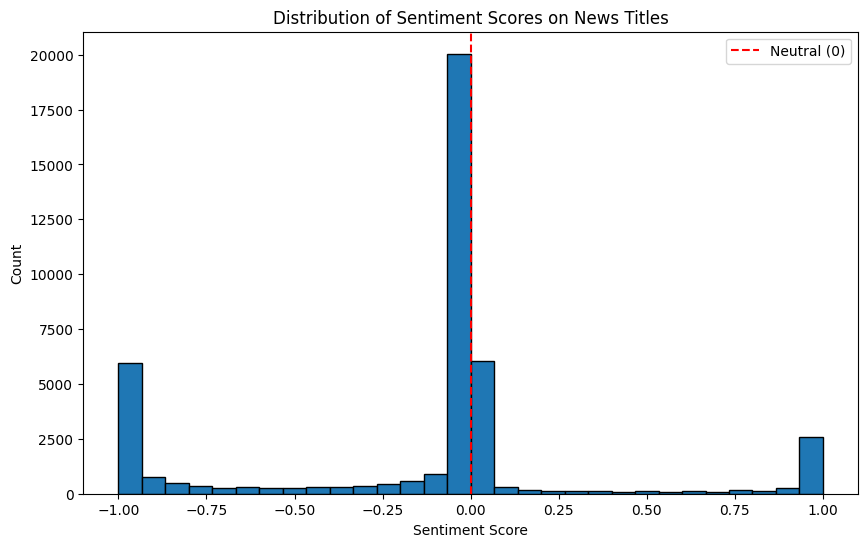


最正面样本:
  Score: 1.000 | Starmer: UK will be 'open for business' under Labour Labour 
  Score: 1.000 | Eintracht Frankfurt v Rangers: Roofe offers boost for Scots'
  Score: 1.000 | NHS data sale can fuel tech boom - Blair and Hague The forme
  Score: 1.000 | Arsenal 3-0 Bodo/Glimt: Arsenal ease to victory over Bodo/Gl
  Score: 1.000 | Warm weather in June boosts UK economy Higher temperatures h

最负面样本:
  Score: -1.000 | The Papers: 'UK heads into recession' and 'tax cut bonanza' 
  Score: -1.000 | E3: Once world's biggest gaming show permanently axed The an
  Score: -1.000 | Brexit: Progress on trade deals slower than promised The UK 
  Score: -1.000 | Parents lose hope as report says Send system broken The spec
  Score: -1.000 | Concerns over failed sports car deal 'overspend' The failed 

模型不确定性:
  平均不确定性: 0.294
  高不确定性样本(>0.5): 12221 条


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("02_A_finbert/bbc_output/bbc_news_sentiment_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# 查看最高和最低的几个样本
print("\n最正面样本:")
for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['text'][:60]}")

print("\n最负面样本:")
for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  Score: {row['sentiment_score']:.3f} | {row['text'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")